### Imports

In [51]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import seaborn as sns
from sklearn.svm import SVR, LinearSVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

TAXI_DATA_PATH = "../data/chicago_taxi_2025_clean.parquet"
WEATHER_DATA_PATH = "../data/chicago_weather_2025_hourly.csv"

# Prediction of Demand in Chicago Community Areas

This notebook focuses on forecasting taxi demand in Chicago’s 77 community areas using 4‑hour time windows. The time windows were chosen as this ensures enough data points with values, more granular data will be harder to predict. The goal is to model how demand changes across space and time, capturing patterns such as rush hours, nightlife peaks, and neighborhood‑specific behavior.

---
## Constraints & Known Concerns

### Hard Constraints
- **No lagged demand features**: autoregressive features (e.g. previous window's count, rolling mean of past demand) are not allowed. The model must rely entirely on exogenous features (time, weather, spatial structure).
- **Algorithm**: Support Vector Machine (SVR / LinearSVR).
- **Temporal resolution**: 4-hour time windows. Hourly is too sparse for low-traffic areas; daily loses too much intra-day signal.
- **Spatial resolution**: Chicago's 77 community areas.

### Dataset Imbalance — Primary Concern
The dataset is severely imbalanced across community areas, both in row count and in demand magnitude:

| | Rows (4h windows) | Peak demand (trips/4h) |
|---|---|---|
| CA 8 – Near North Side | 2,190 (100%) | ~1,916 |
| CA 32 – Loop | 2,190 (100%) | high |
| CA 18 – Montclare | 543 (25%) | ~5 |
| CA 63 – Armour Square | 574 (26%) | ~5 |

- **Row imbalance**: sparse areas are only present in the ~25% of 4h windows where at least one trip occurred. Missing windows are absent from the dataset, not represented as zeros (zero-filling was tested but hurt performance — see git history).
- **Demand scale imbalance**: CA 8 can have 400× more trips than the least active areas in the same time window. A single model trained on all areas is dominated by high-traffic areas.
- **Consequence**: a good overall R² could be driven almost entirely by fitting CA 8, CA 32, and CA 76 well, while predictions for sparse areas may be very poor.

### Other Known Issues
- **Random train/test split**: `train_test_split(random_state=42)` shuffles rows randomly. For time-series data the correct approach is a chronological split (train on earlier months, test on later months) to avoid future data leaking into training. This is kept for now for simplicity but inflates reported R².
- **Heavy-tailed target distribution**: raw trip counts range from 1 to 1,916 with a median of 4. A log-transform (`log1p`) is applied before training and inverted (`expm1`) after prediction. Metrics are reported in original trip-count scale.
- **LinearSVR instead of SVR**: The dataset (~137k rows) is too large for the standard kernel SVR solver (libsvm scales O(n²)–O(n³)). LinearSVR (liblinear, O(n)) is used for the linear baseline. The GridSearch with non-linear kernels is commented out and would require subsampling.
- **Community area encoding**: Raw area numbers are not ordinal. One-hot encoding (76 dummy variables) is used as area fixed effects — the model learns a separate intercept per area. This is correct but means the model cannot generalise to unseen areas.
- **POI features are time-invariant**: POI counts per area are static — they capture structural demand-generating capacity but not changes over time (new venues opening, closures, etc.).
- **Weather features**: `apparent_temperature` dropped (r > 0.95 correlation with `temperature_2m`). `weather_code` dropped (WMO codes are non-ordinal; averaging them over 4h is meaningless).

---

In [52]:
#Load taxi data and weather data
taxi_data = pd.read_parquet(TAXI_DATA_PATH)
weather_data = pd.read_csv(WEATHER_DATA_PATH)


In [53]:
taxi_data["pickup_community_area"].value_counts()

pickup_community_area
8     1423672
76    1229276
32    1018900
28     637638
33     219372
       ...   
57       1489
64       1384
20        750
63        738
18        715
Name: count, Length: 77, dtype: Int64

Community Area 8 has by far the most trips (1.4M), but the model is trained on all 77 community areas so it can generalise across different demand levels and spatial characteristics.

In [54]:
# Aggregate trips to hourly (area, hour) pairs
taxi_data['trip_start_timestamp_rounded'] = pd.to_datetime(taxi_data['trip_start_timestamp']).dt.floor('h')
taxi_data_feats = taxi_data.groupby([taxi_data['pickup_community_area'], taxi_data['trip_start_timestamp_rounded']]).size().reset_index(name='count')
taxi_data_feats = taxi_data_feats.rename(columns={'pickup_community_area': 'community_area', 'trip_start_timestamp_rounded': 'timestamp'})

# Join weather data with taxi data on timestamp
weather_data['datetime'] = pd.to_datetime(weather_data['datetime'])
taxi_data_feats = taxi_data_feats.join(weather_data.set_index('datetime'), on='timestamp', how='left', rsuffix='_weather')

In [55]:
taxi_data_feats.info()
taxi_data_feats.head()

<class 'pandas.DataFrame'>
RangeIndex: 386163 entries, 0 to 386162
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   community_area        386163 non-null  Int64         
 1   timestamp             386163 non-null  datetime64[us]
 2   count                 386163 non-null  int64         
 3   temperature_2m        386163 non-null  float64       
 4   apparent_temperature  386163 non-null  float64       
 5   precipitation         386163 non-null  float64       
 6   snowfall              386163 non-null  float64       
 7   wind_speed_10m        386163 non-null  float64       
 8   cloud_cover           386163 non-null  int64         
 9   weather_code          386163 non-null  int64         
 10  weather_description   386163 non-null  str           
dtypes: Int64(1), datetime64[us](1), float64(5), int64(3), str(1)
memory usage: 36.4 MB


,community_area,timestamp,count,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,weather_code,weather_description
0,1,2025-01-01 00:00:00,2,0.7,-3.6,0.0,0.00,8.6,100,3,Overcast
1,1,2025-01-01 01:00:00,5,0.8,-3.5,0.0,0.00,8.1,100,3,Overcast
2,1,2025-01-01 02:00:00,4,0.6,-3.7,0.0,0.00,8.8,100,3,Overcast
3,1,2025-01-01 03:00:00,4,0.2,-4.8,0.1,0.07,10.7,100,71,Slight snowfall
4,1,2025-01-01 04:00:00,6,-0.2,-5.3,0.0,0.00,10.3,100,3,Overcast


## POI Feature Engineering

POI data was sourced from OpenStreetMap via Overpass Turbo and covers all tagged nodes in Chicago. The data is matched to community areas using a spatial join, so the resolution aligns with the prediction target.

**Included categories:** `amenity`, `public_transport`, `railway`, `tourism`, `office`, `aeroway`, `shop`, `leisure`, `healthcare` — these generate or attract taxi trips (transit hubs, restaurants, hotels, business districts, the airport).

**Excluded categories:**
- `natural` (26,531 entries): parks, trees, and water bodies do not generate taxi demand.
- `man_made` (5,479 entries): covers infrastructure like lamp posts and towers — too broad and not demand-generating.
- `craft` (112 entries): very few data points, no meaningful signal.
- `historic` (366 entries): marginal demand signal; relevant tourism attraction is already captured by the `tourism` category.

In [56]:
gdf_poi = gpd.read_file('../data/poi_chicago.geojson')
community_areas = gpd.read_file('../data/community_areas_chicago.geojson')

gdf_poi = gdf_poi.to_crs(community_areas.crs)

# Categories to include — see markdown above for excluded categories
poi_categories = ['amenity', 'public_transport', 'railway', 'tourism', 'office', 'aeroway', 'shop', 'leisure', 'healthcare']

# Spatial join: assign each POI point to its community area
poi_joined = gpd.sjoin(
    gdf_poi[poi_categories + ['geometry']],
    community_areas[['area_numbe', 'geometry']],
    how='left',
    predicate='within'
)

# Count non-null entries per category per community area
poi_features = pd.DataFrame({
    f'poi_{col}': poi_joined[poi_joined[col].notna()].groupby('area_numbe').size()
    for col in poi_categories
}).reset_index()

poi_features['area_numbe'] = poi_features['area_numbe'].astype(int)
poi_features = poi_features.rename(columns={'area_numbe': 'community_area'})
poi_features = poi_features.fillna(0)

print(f"POI features computed for {len(poi_features)} community areas")
poi_features[poi_features['community_area'] == 8]

POI features computed for 77 community areas


,community_area,poi_amenity,poi_public_transport,poi_railway,poi_tourism,poi_office,poi_aeroway,poi_shop,poi_leisure,poi_healthcare
75,8,1365,468,96.0,88.0,51.0,0.0,379,68.0,29.0


## Prediction for All Community Areas

`weather_code` is excluded from the feature set. It follows the WMO weather interpretation code standard, which is **not ordinal** — for example, code 71 (slight snowfall) and code 3 (overcast) have no meaningful numeric distance between them. Averaging these codes over a 4-hour window produces values that correspond to no real weather condition and would mislead the model.

In [57]:
df_all = taxi_data_feats.copy()
df_all.drop(columns=['weather_description'], inplace=True)

df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])
# Make 4-hour time windows
df_all['timestamp_4h'] = df_all['timestamp'].dt.floor('4h')
df_all = df_all.groupby(['community_area', 'timestamp_4h']).agg({
    'count': 'sum',
    'temperature_2m': 'mean',
    'apparent_temperature': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
    'wind_speed_10m': 'mean',
    'cloud_cover': 'mean',
}).reset_index()

df_all['hour'] = df_all['timestamp_4h'].dt.hour
df_all['day_of_week'] = df_all['timestamp_4h'].dt.dayofweek
df_all['month'] = df_all['timestamp_4h'].dt.month

# Cyclic features for hour, day of week, and month
df_all['hour_sin'] = np.sin(2 * np.pi * df_all['hour'] / 24)
df_all['hour_cos'] = np.cos(2 * np.pi * df_all['hour'] / 24)
df_all['day_of_week_sin'] = np.sin(2 * np.pi * df_all['day_of_week'] / 7)
df_all['day_of_week_cos'] = np.cos(2 * np.pi * df_all['day_of_week'] / 7)
df_all['month_sin'] = np.sin(2 * np.pi * df_all['month'] / 12)
df_all['month_cos'] = np.cos(2 * np.pi * df_all['month'] / 12)

# Weekend flag: Saturday (5) and Sunday (6)
df_all['is_weekend'] = (df_all['timestamp_4h'].dt.dayofweek >= 5).astype(int)

# US federal public holidays 2025
us_holidays_2025 = pd.to_datetime([
    '2025-01-01',  # New Year's Day
    '2025-01-20',  # Martin Luther King Jr. Day
    '2025-02-17',  # Presidents' Day
    '2025-05-26',  # Memorial Day
    '2025-06-19',  # Juneteenth National Independence Day
    '2025-07-04',  # Independence Day
    '2025-09-01',  # Labor Day
    '2025-10-13',  # Columbus Day
    '2025-11-11',  # Veterans Day
    '2025-11-27',  # Thanksgiving Day
    '2025-12-25',  # Christmas Day
])
df_all['is_holiday'] = df_all['timestamp_4h'].dt.date.isin(us_holidays_2025.date).astype(int)

df_all.drop(columns=['timestamp_4h', 'hour', 'day_of_week', 'month'], inplace=True)

print(f"Total rows: {len(df_all)} ({df_all['community_area'].nunique()} areas × ~2190 time windows)")
df_all.info()

Total rows: 137680 (77 areas × ~2190 time windows)
<class 'pandas.DataFrame'>
RangeIndex: 137680 entries, 0 to 137679
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   community_area        137680 non-null  Int64  
 1   count                 137680 non-null  int64  
 2   temperature_2m        137680 non-null  float64
 3   apparent_temperature  137680 non-null  float64
 4   precipitation         137680 non-null  float64
 5   snowfall              137680 non-null  float64
 6   wind_speed_10m        137680 non-null  float64
 7   cloud_cover           137680 non-null  float64
 8   hour_sin              137680 non-null  float64
 9   hour_cos              137680 non-null  float64
 10  day_of_week_sin       137680 non-null  float64
 11  day_of_week_cos       137680 non-null  float64
 12  month_sin             137680 non-null  float64
 13  month_cos             137680 non-null  float64
 14  is_weekend  

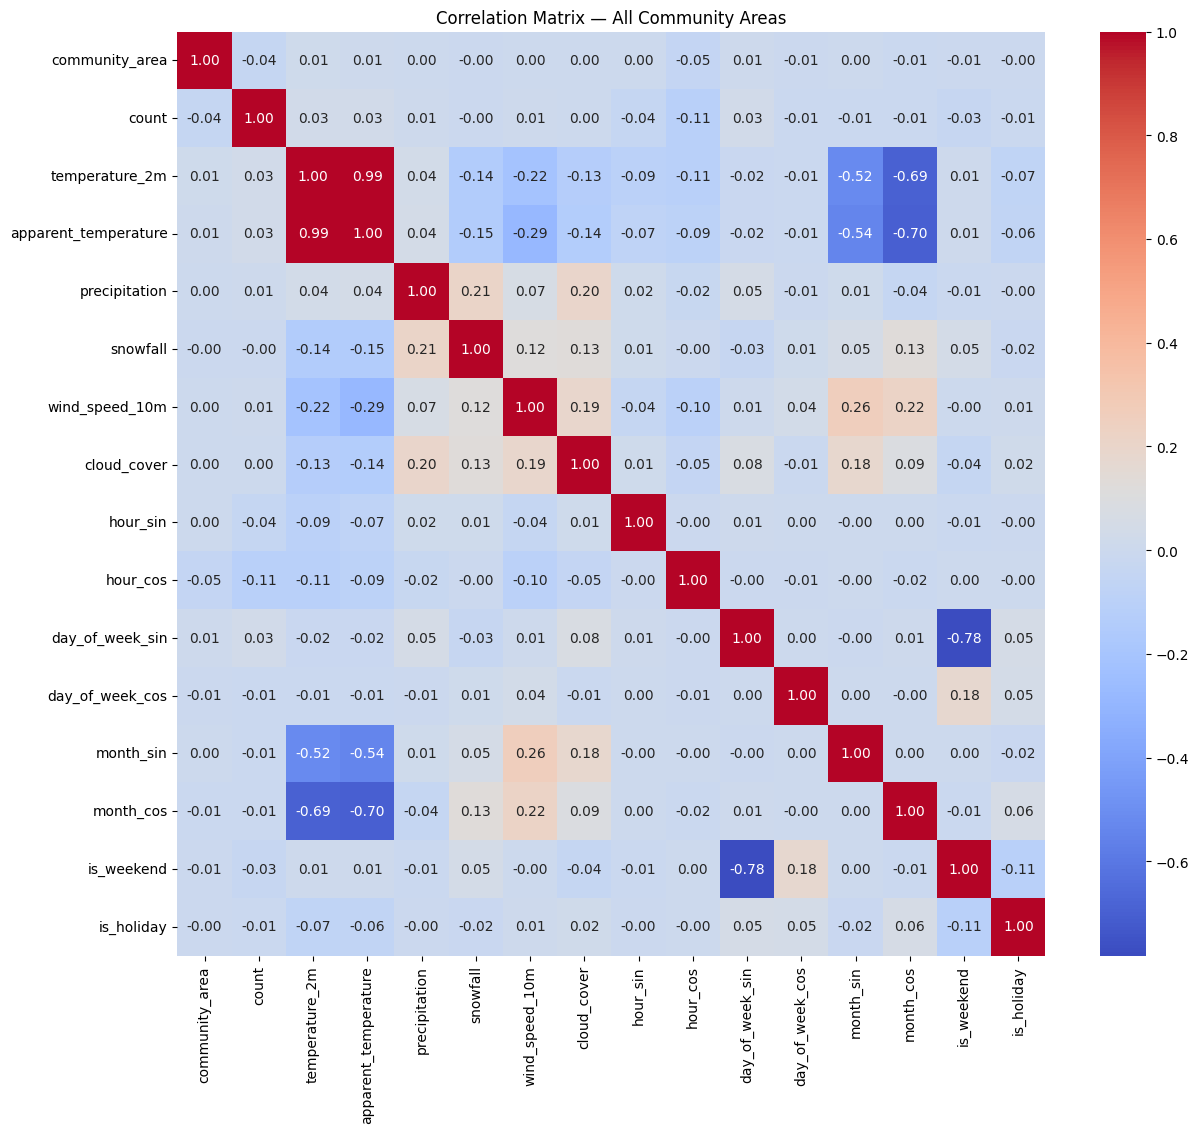

In [58]:
# Correlation matrix (sample to keep heatmap readable)
corr_matrix = df_all.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix — All Community Areas')
plt.show()

The correlation matrix shows that `apparent_temperature` and `temperature_2m` are very highly correlated. Keeping both would introduce multicollinearity without adding new predictive information. `apparent_temperature` is therefore dropped — `temperature_2m` is the more direct physical measurement.

In [59]:
df_all.drop(columns=['apparent_temperature'], inplace=True)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 137680 entries, 0 to 137679
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   community_area   137680 non-null  Int64  
 1   count            137680 non-null  int64  
 2   temperature_2m   137680 non-null  float64
 3   precipitation    137680 non-null  float64
 4   snowfall         137680 non-null  float64
 5   wind_speed_10m   137680 non-null  float64
 6   cloud_cover      137680 non-null  float64
 7   hour_sin         137680 non-null  float64
 8   hour_cos         137680 non-null  float64
 9   day_of_week_sin  137680 non-null  float64
 10  day_of_week_cos  137680 non-null  float64
 11  month_sin        137680 non-null  float64
 12  month_cos        137680 non-null  float64
 13  is_weekend       137680 non-null  int64  
 14  is_holiday       137680 non-null  int64  
dtypes: Int64(1), float64(11), int64(3)
memory usage: 15.9 MB


### POI Features & Area Encoding

POI counts are merged by `community_area` as static structural features. In the per-area model approach they are **not passed to the SVR** — within a single area every POI column has zero variance, which would cause StandardScaler to divide by zero. They become relevant again if a single cross-area model is used instead.

`community_area` is kept as a column for filtering in the training loop and is never passed as a model feature.

In [60]:
# Merge static POI features for all community areas
df_all = df_all.merge(poi_features, on='community_area', how='left')

# community_area is kept for splitting the data in the per-area training loop.
# POI features are included in df_all but excluded from per-area model inputs:
# within a single area every POI column is constant (zero variance), which would
# cause StandardScaler to divide by zero.
print(f"Shape after POI merge: {df_all.shape}")
df_all.info()

Shape after POI merge: (137680, 24)
<class 'pandas.DataFrame'>
RangeIndex: 137680 entries, 0 to 137679
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   community_area        137680 non-null  Int64  
 1   count                 137680 non-null  int64  
 2   temperature_2m        137680 non-null  float64
 3   precipitation         137680 non-null  float64
 4   snowfall              137680 non-null  float64
 5   wind_speed_10m        137680 non-null  float64
 6   cloud_cover           137680 non-null  float64
 7   hour_sin              137680 non-null  float64
 8   hour_cos              137680 non-null  float64
 9   day_of_week_sin       137680 non-null  float64
 10  day_of_week_cos       137680 non-null  float64
 11  month_sin             137680 non-null  float64
 12  month_cos             137680 non-null  float64
 13  is_weekend            137680 non-null  int64  
 14  is_holiday            13768

In [61]:
# Features used for every per-area model.
# POI columns are excluded (constant per area → zero variance → StandardScaler fails).
# community_area is excluded (used only for filtering).
FEATURE_COLS = [
    'temperature_2m', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover',
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos', 'is_weekend', 'is_holiday'
]

areas = sorted(df_all['community_area'].unique())
print(f"Training one RBF SVR per community area ({len(areas)} models)...\n")

area_results = []
models = {}
all_y_test = []
all_y_pred = []

for area in areas:
    df_area = df_all[df_all['community_area'] == area]

    X = df_area[FEATURE_COLS]
    y = np.log1p(df_area['count'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
    ])
    model.fit(X_train, y_train)

    y_pred_area  = np.expm1(model.predict(X_test))
    y_test_area  = np.expm1(y_test)

    area_results.append({
        'community_area': int(area),
        'n_train': len(X_train),
        'n_test':  len(X_test),
        'r2':  round(r2_score(y_test_area, y_pred_area), 4),
        'mse': round(mean_squared_error(y_test_area, y_pred_area), 2)
    })
    models[int(area)] = model
    all_y_test.extend(y_test_area.values)
    all_y_pred.extend(y_pred_area)

results_df = pd.DataFrame(area_results)
overall_r2  = r2_score(all_y_test, all_y_pred)
overall_mse = mean_squared_error(all_y_test, all_y_pred)

print(f"Overall R² (all areas pooled): {overall_r2:.3f}")
print(f"Overall MSE:                   {overall_mse:.2f}")
print(f"Median R² per area:            {results_df['r2'].median():.3f}")
print(f"Mean R² per area:              {results_df['r2'].mean():.3f}")
print(f"\nTop 10 areas by R²:")
print(results_df.nlargest(10, 'r2')[['community_area', 'n_train', 'r2', 'mse']].to_string(index=False))
print(f"\nBottom 10 areas by R²:")
print(results_df.nsmallest(10, 'r2')[['community_area', 'n_train', 'r2', 'mse']].to_string(index=False))

Training one RBF SVR per community area (77 models)...

Overall R² (all areas pooled): 0.922
Overall MSE:                   1809.61
Median R² per area:            0.218
Mean R² per area:              0.056

Top 10 areas by R²:
 community_area  n_train     r2      mse
             28     1752 0.8716  8132.06
             32     1752 0.8422 19893.00
             38     1638 0.8160    35.23
              8     1752 0.8036 36295.08
             41     1611 0.7893    81.57
             43     1713 0.7817    33.12
             35     1697 0.7647    58.01
             77     1743 0.7617   133.12
              3     1748 0.7548   373.12
              2     1743 0.7517    34.17

Bottom 10 areas by R²:
 community_area  n_train      r2  mse
             57      789 -1.6989 1.63
             63      459 -1.6801 0.80
             18      434 -1.3448 0.65
             20      472 -0.9968 0.75
             64      722 -0.9578 0.85
             30     1231 -0.9276 4.86
             74      918 -0.8712

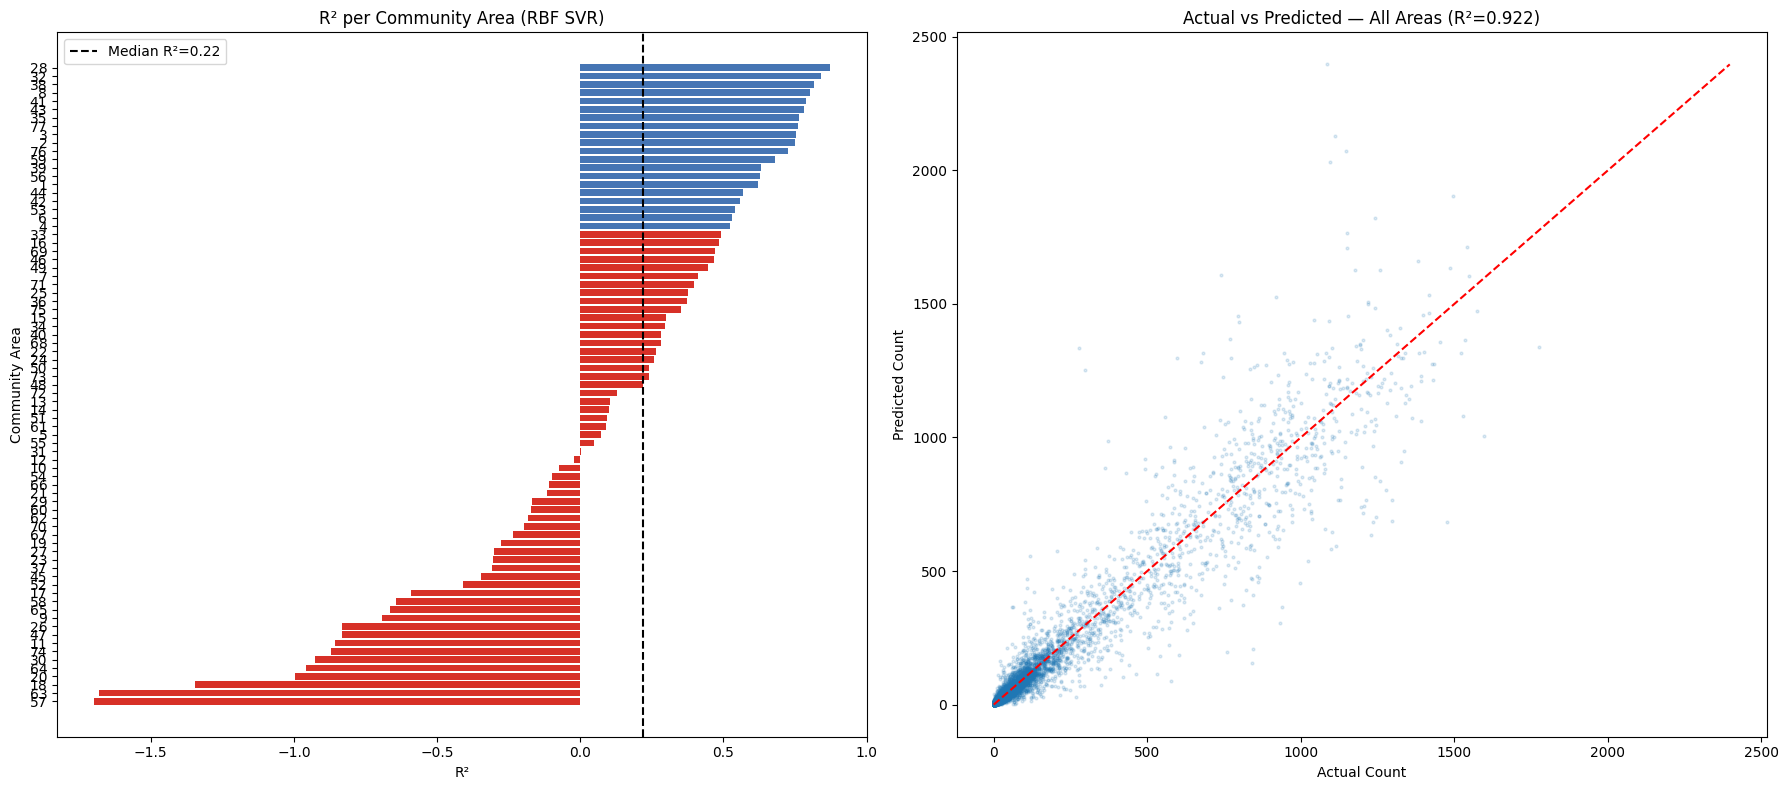

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: R² per area, sorted ---
results_sorted = results_df.sort_values('r2')
colors = ['#d73027' if r < 0.5 else '#4575b4' for r in results_sorted['r2']]
axes[0].barh(results_sorted['community_area'].astype(str), results_sorted['r2'], color=colors)
axes[0].axvline(results_df['r2'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f"Median R²={results_df['r2'].median():.2f}")
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Community Area')
axes[0].set_title('R² per Community Area (RBF SVR)')
axes[0].legend()

# --- Right: overall scatter ---
axes[1].scatter(all_y_test, all_y_pred, alpha=0.15, s=4)
max_val = max(max(all_y_test), max(all_y_pred))
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Count')
axes[1].set_ylabel('Predicted Count')
axes[1].set_title(f'Actual vs Predicted — All Areas (R²={overall_r2:.3f})')

plt.tight_layout()
plt.show()

In [67]:
# GridSearch for a single community area.
# Per-area datasets (430–1750 training rows) are small enough for full kernel SVR GridSearch
# without any subsampling — this is one of the main advantages of the per-area approach.
# Change AREA_ID to tune a different area. Uncomment the fit block to run.

AREA_ID = 8

df_area_gs = df_all[df_all['community_area'] == AREA_ID]
X_gs = df_area_gs[FEATURE_COLS]
y_gs = np.log1p(df_area_gs['count'])

X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X_gs, y_gs, test_size=0.2, random_state=42
)

pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVR())
])

param_grid = {
    'svm__C':       [10, 100, 1000],
    'svm__epsilon': [0.001, 0.01, 0.1],
    'svm__gamma':   ['scale', 0.01],
    'svm__kernel':  ['rbf']   # rbf is almost always best for this type of data
}

grid_search_area = GridSearchCV(
    estimator=pipeline_gs,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search_area.fit(X_train_gs, y_train_gs)

print(f"Best params for CA {AREA_ID}:", grid_search_area.best_params_)
print(f"Best CV R²: {grid_search_area.best_score_:.3f}")
y_pred_gs      = np.expm1(grid_search_area.predict(X_test_gs))
y_test_gs_act  = np.expm1(y_test_gs)
print(f"Test R²:  {r2_score(y_test_gs_act, y_pred_gs):.3f}")
print(f"Test MSE: {mean_squared_error(y_test_gs_act, y_pred_gs):.2f}")

Best params for CA 8: {'svm__C': 10, 'svm__epsilon': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV R²: 0.913
Test R²:  0.863
Test MSE: 25406.52


In [ ]:
# Plots for GridSearch results on a single area — run after uncommenting the fit block above.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(y_test_gs_act.reset_index(drop=True)[:100], label='Actual', marker='.', linewidth=0.5)
axes[0].plot(y_pred_gs[:100], label='Predicted', marker='.', linewidth=0.5)
axes[0].set_title(f'CA {AREA_ID} — Actual vs Predicted (First 100)')
axes[0].legend()
axes[1].scatter(y_test_gs_act, y_pred_gs, alpha=0.5)
axes[1].plot([y_test_gs_act.min(), y_test_gs_act.max()],
             [y_test_gs_act.min(), y_test_gs_act.max()], 'r--')
axes[1].set_title(f'CA {AREA_ID} — Scatter')
plt.tight_layout()
plt.show()